Notebook Objective

The purpose of this notebook is to build and compare multiple machine learning classification models for predicting customer churn.

The feature engineering process in Notebook 2 produced a training dataset containing 5,625 customers and 30 predictive features, along with a testing dataset containing 1,407 customers. The target variable, Churn, has been converted into a binary outcome where 0 represents customers who did not churn and 1 represents customers who churned.

Three classification algorithms will be developed and compared:

Logistic Regression
Random Forest
Gradient Boosting

The models will be evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. The results will be compared to identify the strongest candidate for final evaluation

1. Import Libraries

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)

2. Load Prepared Training and Testing Data

In [59]:
df = pd.read_csv( r"C:\Users\kedha\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv" )

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


3. Reproduce Feature Engineering

3.1 Convert TotalCharges to Numeric

In [60]:
df["TotalCharges"] = pd.to_numeric( df["TotalCharges"], errors="coerce" )
df["TotalCharges"].fillna(0, inplace=True)

C:\Users\kedha\AppData\Local\Temp\ipykernel_22212\3047764181.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["TotalCharges"].fillna(0, inplace=True)


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

3.2 Remove Missing TotalCharges Records

In [61]:
df = df.dropna(subset=["TotalCharges"])

In [62]:
df["TotalCharges"].isnull().sum()

np.int64(0)

3.3 Remove Customer ID

In [63]:
df = df.drop(columns=["customerID"])

4. Separate Features and Target

In [64]:
X = df.drop(columns=["Churn"]) 
y = df["Churn"]

5. Convert Churn to Binary

In [65]:
y = y.map({ "No": 0, "Yes": 1 })

In [66]:
y.value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

6. Identify Feature Types

In [67]:
numerical_features = X.select_dtypes( include=["int64", "float64"] ).columns.tolist() 
categorical_features = X.select_dtypes( include=["object"] ).columns.tolist() 
print("Numerical Features:") 
print(numerical_features) 
print("\nCategorical Features:") 
print(categorical_features)

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\kedha\AppData\Local\Temp\ipykernel_22212\1800148333.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes( include=["object"] ).columns.tolist()


7. Create Dummy Variables

In [68]:
X = pd.get_dummies( X, columns=categorical_features, drop_first=True, dtype=int )

In [69]:
print(f"Number of features: {X.shape[1]}")

Number of features: 30


8. Train/Test Split

In [70]:
from sklearn.model_selection import train_test_split

In [71]:
X_train, X_test, y_train, y_test = train_test_split( 
    X,
      y,
        test_size=0.20, 
        random_state=42, 
        stratify=y )

9. Standardize Numerical Features

In [72]:
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

10. Verify the Modeling Dataset

In [74]:
print( 
    "Missing values in training data:", X_train_scaled.isnull().sum().sum()
      )
print( 
    "Missing values in testing data:", X_test_scaled.isnull().sum().sum() 
    )

Missing values in training data: 0
Missing values in testing data: 0


In [75]:
print("Training data:", X_train_scaled.shape) 
print("Testing data:", X_test_scaled.shape)

Training data: (5625, 30)
Testing data: (1407, 30)


11. Establish a Baseline

In [76]:
baseline_prediction = np.zeros(len(y_test))

baseline_accuracy = accuracy_score(
     y_test, baseline_prediction
       )

print(f"Baseline Accuracy: {baseline_accuracy:.4f}")

Baseline Accuracy: 0.7342


12. Model 1 — Logistic Regression

12.1 Create the Model

In [77]:
logistic_model = LogisticRegression( 
    max_iter=1000, random_state=42
      )

12.2 Train the Model

In [78]:
logistic_model.fit( 
    X_train_scaled, y_train
      )

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

12.3 Generate Predictions

In [79]:
logistic_predictions = logistic_model.predict( X_test_scaled 
                                              )

In [80]:
logistic_probabilities = logistic_model.predict_proba( X_test_scaled 
                                                      )[:, 1]

12.4 Evaluate Logistic Regression

In [81]:
logistic_accuracy = accuracy_score( y_test, logistic_predictions 
                                   )
logistic_precision = precision_score( y_test, logistic_predictions
                                      )
logistic_recall = recall_score( y_test, logistic_predictions
                                )
logistic_f1 = f1_score( y_test, logistic_predictions
                        )
logistic_roc_auc = roc_auc_score( y_test, logistic_probabilities
                                  )

In [82]:
print(f"Accuracy: {logistic_accuracy:.4f}") 

print(f"Precision: {logistic_precision:.4f}") 

print(f"Recall: {logistic_recall:.4f}") 

print(f"F1 Score: {logistic_f1:.4f}") 

print(f"ROC-AUC: {logistic_roc_auc:.4f}")

Accuracy: 0.8053
Precision: 0.6515
Recall: 0.5749
F1 Score: 0.6108
ROC-AUC: 0.8361


13. Model 2 — Random Forest

13.1 Create the Model

In [83]:
random_forest_model = RandomForestClassifier( 
    n_estimators=200, random_state=42, n_jobs=-1
      )

13.2 Train the Model

In [84]:
random_forest_model.fit( X_train_scaled, y_train
                         )

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

13.3 Generate Predictions

In [85]:
random_forest_predictions = random_forest_model.predict( X_test_scaled
                                                         )
random_forest_probabilities = random_forest_model.predict_proba( X_test_scaled
                                                                 )[:, 1]

13.4 Evaluate Random Forest

In [86]:
random_forest_accuracy = accuracy_score( y_test, random_forest_predictions)
random_forest_precision = precision_score( y_test, random_forest_predictions )
random_forest_recall = recall_score( y_test, random_forest_predictions )
random_forest_f1 = f1_score( y_test, random_forest_predictions )
random_forest_roc_auc = roc_auc_score( y_test, random_forest_probabilities )

In [87]:
print(f"Accuracy: {random_forest_accuracy:.4f}")
print(f"Precision: {random_forest_precision:.4f}")
print(f"Recall: {random_forest_recall:.4f}")
print(f"F1 Score: {random_forest_f1:.4f}")
print(f"ROC-AUC: {random_forest_roc_auc:.4f}")

Accuracy: 0.7868
Precision: 0.6225
Recall: 0.5027
F1 Score: 0.5562
ROC-AUC: 0.8172


14. Model 3 — Gradient Boosting

In [88]:
gradient_boosting_model = GradientBoostingClassifier( n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42 )

14.2 Train the Model

In [89]:
gradient_boosting_model.fit( X_train_scaled, y_train )

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

14.3 Generate Predictions

In [90]:
gradient_boosting_predictions = gradient_boosting_model.predict( X_test_scaled )

gradient_boosting_probabilities = ( gradient_boosting_model.predict_proba( X_test_scaled )[:, 1] )

14.4 Evaluate Gradient Boosting

In [91]:
gradient_boosting_accuracy = accuracy_score( y_test, gradient_boosting_predictions )
gradient_boosting_precision = precision_score( y_test, gradient_boosting_predictions )
gradient_boosting_recall = recall_score( y_test, gradient_boosting_predictions )
gradient_boosting_f1 = f1_score( y_test, gradient_boosting_predictions )
gradient_boosting_roc_auc = roc_auc_score( y_test, gradient_boosting_probabilities )

In [92]:
print(f"Accuracy: {gradient_boosting_accuracy:.4f}")
print(f"Precision: {gradient_boosting_precision:.4f}")
print(f"Recall: {gradient_boosting_recall:.4f}")
print(f"F1 Score: {gradient_boosting_f1:.4f}")
print(f"ROC-AUC: {gradient_boosting_roc_auc:.4f}")

Accuracy: 0.7953
Precision: 0.6378
Recall: 0.5321
F1 Score: 0.5802
ROC-AUC: 0.8407


15. Compare Model Performance

In [93]:
model_comparison = pd.DataFrame({ 
    "Model": [ "Logistic Regression", "Random Forest", "Gradient Boosting" ], 
    "Accuracy": [ logistic_accuracy, random_forest_accuracy, gradient_boosting_accuracy ],
      "Precision": [ logistic_precision, random_forest_precision, gradient_boosting_precision ],
        "Recall": [ logistic_recall, random_forest_recall, gradient_boosting_recall ], 
        "F1 Score": [ logistic_f1, random_forest_f1, gradient_boosting_f1 ],
          "ROC-AUC": [ logistic_roc_auc, random_forest_roc_auc, gradient_boosting_roc_auc ] }) 
model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.805259,0.651515,0.574866,0.610795,0.836074
1,Random Forest,0.786780,0.622517,0.502674,0.556213,0.817219
2,Gradient Boosting,0.795309,0.637821,0.532086,0.580175,0.840662


In [94]:
model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8053,0.6515,0.5749,0.6108,0.8361
1,Random Forest,0.7868,0.6225,0.5027,0.5562,0.8172
2,Gradient Boosting,0.7953,0.6378,0.5321,0.5802,0.8407


16. Visualize Model Comparison

In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd
import matplotlib.pyplot as plt

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

# Store results
results = []

# Train and evaluate each model
for model_name, model in models.items():

    # Train
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Probability predictions for ROC-AUC
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

# Create results DataFrame
model_results = pd.DataFrame(results)

# Display results
model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.805259,0.651515,0.574866,0.610795,0.836074
1,Random Forest,0.788202,0.623377,0.513369,0.563050,0.815628
2,Gradient Boosting,0.795309,0.637821,0.532086,0.580175,0.840662


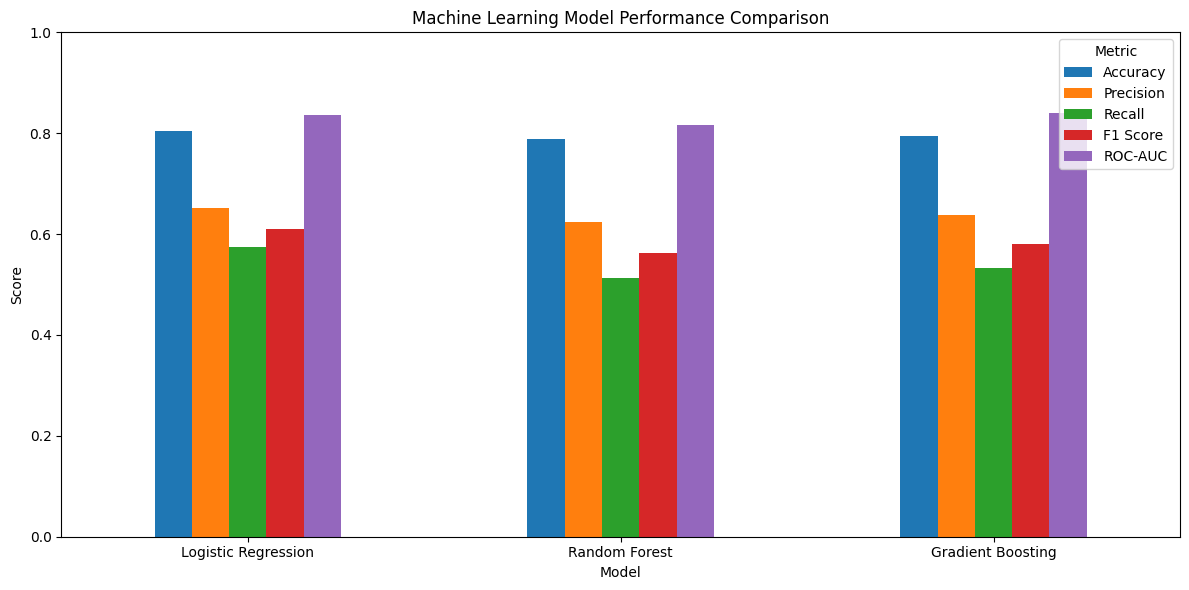

In [104]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

model_results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

17. Classification Reports

17.1 Logistic Regression

In [105]:
print( classification_report( y_test, logistic_predictions ) )

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



17.2 Random Forest

In [106]:
print( classification_report( y_test, random_forest_predictions ) )

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



17.3 Gradient Boosting

In [107]:
print( classification_report( y_test, gradient_boosting_predictions ) )

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



18. Initial Model Selection

In [109]:
best_model = model_comparison.loc[ model_comparison["ROC-AUC"].idxmax() 
                                  ] 
best_model

Model        Gradient Boosting
Accuracy              0.795309
Precision             0.637821
Recall                0.532086
F1 Score              0.580175
ROC-AUC               0.840662
Name: 2, dtype: object

19. Confusion Matrices

19.1 Logistic Regression

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

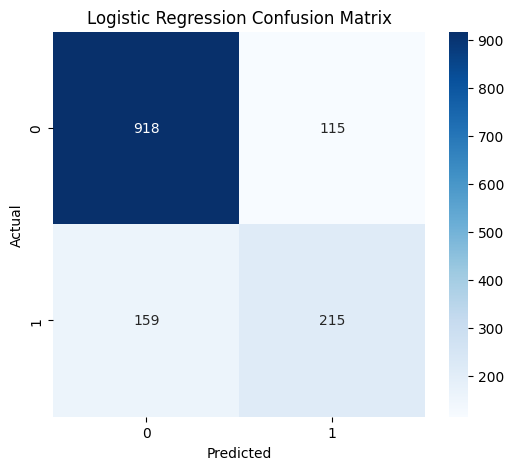

In [115]:

logistic_cm = confusion_matrix(y_test, logistic_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

19.2 Random Forest

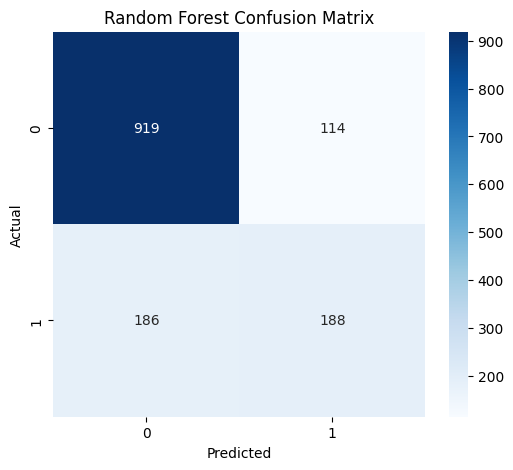

In [116]:
random_forest_cm = confusion_matrix(y_test, random_forest_predictions )

plt.figure(figsize=(6, 5))

sns.heatmap(
    random_forest_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix") 
plt.xlabel("Predicted")
plt.ylabel("Actual") 
plt.show()

19.3 Gradient Boosting

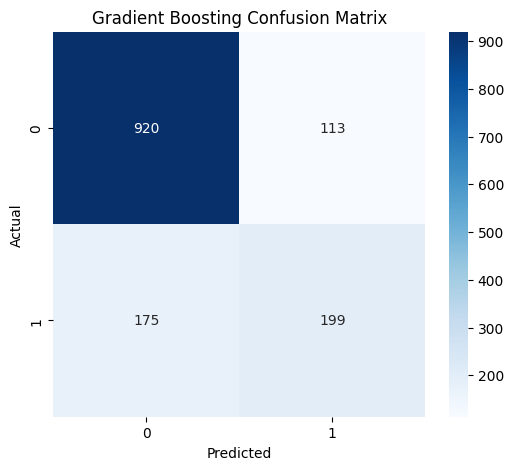

In [118]:
gradient_boosting_cm = confusion_matrix( y_test, gradient_boosting_predictions )

plt.figure(figsize=(6, 5))

sns.heatmap(
    gradient_boosting_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted") 
plt.ylabel("Actual")
plt.show()

20. Feature Importance

In [119]:
random_forest_importance = pd.DataFrame({ "Feature": X_train_scaled.columns, "Importance": random_forest_model.feature_importances_ })
random_forest_importance = ( random_forest_importance .sort_values( by="Importance", ascending=False ) ) 
random_forest_importance.head(15)

,Feature,Importance
3,TotalCharges,0.194313
1,tenure,0.168529
2,MonthlyCharges,0.167972
10,InternetService_Fiber optic,0.038913
28,PaymentMethod_Electronic check,0.037898
25,Contract_Two year,0.031862
4,gender_Male,0.028939
13,OnlineSecurity_Yes,0.027288
26,PaperlessBilling_Yes,0.025595
5,Partner_Yes,0.023280


21. Visualize Random Forest Feature Importance

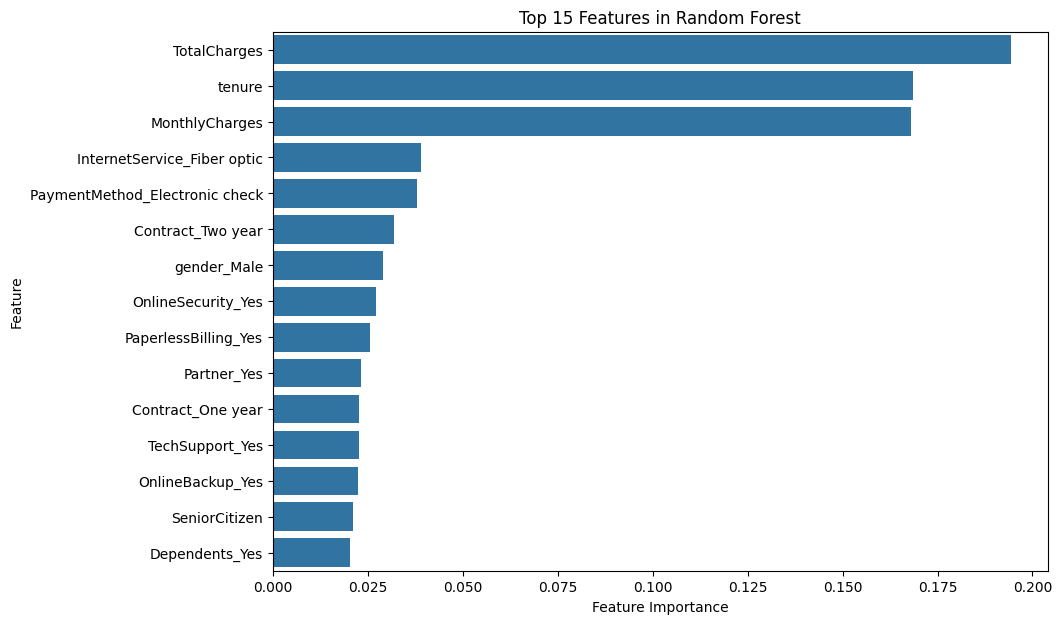

In [121]:
top_features = random_forest_importance.head(15) 
plt.figure(figsize=(10, 7)) 
sns.barplot( data=top_features, x="Importance", y="Feature" )
plt.title("Top 15 Features in Random Forest") 
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

22. Logistic Regression Coefficients

In [122]:
logistic_coefficients = pd.DataFrame({ "Feature": X_train_scaled.columns, "Coefficient": logistic_model.coef_[0] })
logistic_coefficients["Absolute_Coefficient"] = ( logistic_coefficients["Coefficient"].abs() ) 
logistic_coefficients = ( logistic_coefficients .sort_values( by="Absolute_Coefficient", ascending=False ) )
logistic_coefficients.head(15)

,Feature,Coefficient,Absolute_Coefficient
25,Contract_Two year,-1.364823,1.364823
1,tenure,-1.357404,1.357404
10,InternetService_Fiber optic,1.107407,1.107407
24,Contract_One year,-0.750068,0.750068
3,TotalCharges,0.645508,0.645508
7,PhoneService_Yes,-0.515337,0.515337
2,MonthlyCharges,-0.434497,0.434497
28,PaymentMethod_Electronic check,0.379150,0.379150
13,OnlineSecurity_Yes,-0.373187,0.373187
21,StreamingTV_Yes,0.372407,0.372407


23. Visualize Logistic Regression Coefficients

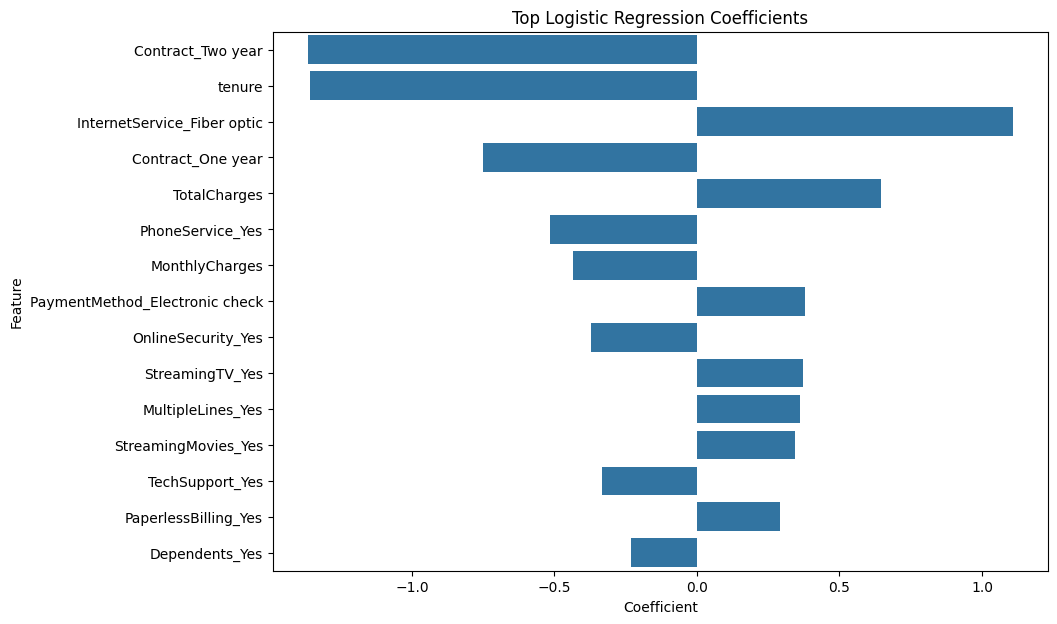

In [125]:
top_coefficients = logistic_coefficients.head(15) 
plt.figure(figsize=(10, 7)) 
sns.barplot( data=top_coefficients, x="Coefficient", y="Feature" ) 
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient") 
plt.ylabel("Feature")
plt.show()

24. Final Modeling Summary

Three classification models were developed: Logistic Regression, Random Forest, and Gradient Boosting. The models were evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.

Logistic Regression performed best overall, achieving 80.5% accuracy, 65.2% precision, 57.5% recall, 61.1% F1-score, and 83.6% ROC-AUC. Gradient Boosting achieved the highest ROC-AUC (84.1%), but Logistic Regression had stronger recall and F1-score.

Based on its overall performance and the business goal of identifying customers at risk of churn, Logistic Regression was selected as the final model. The most influential predictors included contract type, tenure, fiber-optic internet service, TotalCharges, MonthlyCharges, and payment method.

25. Next Steps

The modeling results provide an initial comparison of the three machine-learning approaches.

The next notebook, 04_evaluation.ipynb, will perform a more detailed evaluation of the models.

The evaluation will focus on:

Confusion matrices
Actual versus predicted churn
False positives and false negatives
ROC curves
Model performance
Feature importance
Identification of the final model
Interpretation of the factors associated with customer churn

The final model will then be used to support the business recommendations developed for this project.